<font size="1"> *This notebook is best viewed in jupyter lab/notebook. You may also choose to use Google Colab but some parts of the images/colouring will not be rendered properly.</font> 

<div class="alert alert-block alert-warning">
    
# Assignment

Welcome to task 2 of the assignment! This notebook contains all the code and comments that you need to submit. The places where you need to edit are highlighted in red. Feel free to add in your own markdown for additional comments.

__Submission details: make sure you all your outputs have been generated. Submit this Jupyter Notebook__

<b>Enter you student details below</b>

- <b>Student Name:</b> Wenxing Du
- <b>Student ID:</b> 30171857

<div class="alert alert-block alert-danger">

# Table of Contents
    
* [Libraries](#Libraries)
    
* [Task 2.1: Create dataloader for Face Data and Visualise a few samples](#t2_1)
    
* [Task 2.2: Design your network architecture for AE](#t2_2)
    
* [Task 2.3: Train your model and evaluate the DAE results](#t2_3)
    
* [Task 2.4: Visualise reconstructed images along with the clean data](#t2_4)
    
* [Task 2.5: Compute Peak Signal To Noise Ratio (PSNR)](#t2_5)
    
* [Task 2.6: Discussion Question](#t2_6)

<div class="alert alert-block alert-warning">

# Libraries

Libraries are important as it saves us time from writing our own functions all the time such as graphing, or creating matrices. Brief library descriptions have been added for every library that we import. You may also check the official documentations for more details.

The required libraries are specified in this notebook for you.

In [1]:
# Mount Google Drive
import os
try:
    from google.colab import drive
    colabFlag = True
    
    PATH_DATASETS = '/content/gdrive/MyDrive/...' # Add in your own path here to the folder containing the data
    # mount Google Drive
    drive.mount('/content/gdrive')
    print(f"Using Google Colab with file path {PATH_DATASETS}")
except:
    colabFlag = False

    PATH_DATASETS = os.environ.get("PATH_DATASETS", "./data")

    print(f"Not using Google Colab. File path will be: {PATH_DATASETS}")

Not using Google Colab. File path will be: ./data


In [2]:
# If you run on google colab uncomment bellow comment
# !pip install torchmetrics pytorch-lightning torchvision -qq
# !pip install imutils

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import *

import torch
import torchvision
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split

import pytorch_lightning as pl # Pytorch lightning is a wrapper for pytorch that makes it easier to train models
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.progress import TQDMProgressBar

# Setting seeds for reproducibility
pl.seed_everything(4179)
random.seed(4179)
np.random.seed(4179)

import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'


BATCH_SIZE = 256 if torch.cuda.is_available() else 64
# Define GPU number
GPU_indx = 0
device = torch.device(GPU_indx if torch.cuda.is_available() else 'cpu')
num_workers = 0 # Set to your device

c:\Users\dwx\anaconda3\envs\ECE4179_2\lib\site-packages\transformers\utils\generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
Seed set to 4179


<div class="alert alert-block alert-info">

# DAE: Denoising Autoencoder
    
## What you should do in this task!

In this task you will be training an autoencoder to denoise images using Pytorch and PyTorch Lightning functionalities we have previously encountered!

Use Pytorch and the Pytorch Lightning module class to create an autoencoder architecture in order to denoise (noisy) face data, and train your model using ADAM. The image below shows a denoising autoencoder applied to the MNIST dataset

<img src="figures/denoising_ae_image.png" width="700" align="center">
    
#### In this task, you will work on the following points:
 1. Prepare the dataset and create dataloaders.
 2. Visualise a training sample using the dataloader.
 3. Design the neural network model.
 4. Perform training of the model and evaluation.
 5. Visualise experimental results.
    


<div class="alert alert-block alert-info">

### Task 2.1: Create dataloader for Face Data and Visualise a few samples <a class="anchor" id="t2_1"></a>

Use the **random_split** function to divide the training dataset into Train, Validation and Test. You must use 20% of the training data as Validation data during training and keep 20% as Testing data.

In [3]:
# Create your class for the face data 
# The face data can be reshaped into the shape of (N, 64, 64) where N is the size of the dataset
# It is always recommended to print the shape of the numpy array before reshaping, just to ensure the dimensions are correct

class FaceData(Dataset):
    def __init__(self, transform=None):
        self.images = np.load(PATH_DATASETS + "/face_data.npy")

        # Define your self.images and self.transform
        self.transform = transform 
        print(f"Loaded images with shape: {self.images.shape}")

        # Are there labels in this dataset? Think about what the task is and why there may (or may not be) labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]
    
        # If there is a transform, apply it here to your sample
        if self.transform:
            image = self.transform(image)
           
        return image

In [5]:
# data transform without data augmentation
data_transform = transforms.Compose([
    transforms.ToPILImage(), # PIL [Python Imaging Library] is a Python package to read images. This allows you to use the resize transform.
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(0, 1)
])

# Load in dataloader
train_set = FaceData(transform=data_transform)

# Split the train set into training, validation and test
train_set, val_set = random_split(train_set, [int(len(train_set)*0.6), len(train_set) - int(len(train_set)*0.6)])
val_set, test_set = random_split(val_set, [int(len(val_set)*0.5), len(val_set) - int(len(val_set)*0.5)])

# Create Dataloaders again with features generated from pre-trained CNN model
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
valid_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

Loaded images with shape: (1800, 64, 64)


Let's add some noise to the data samples!

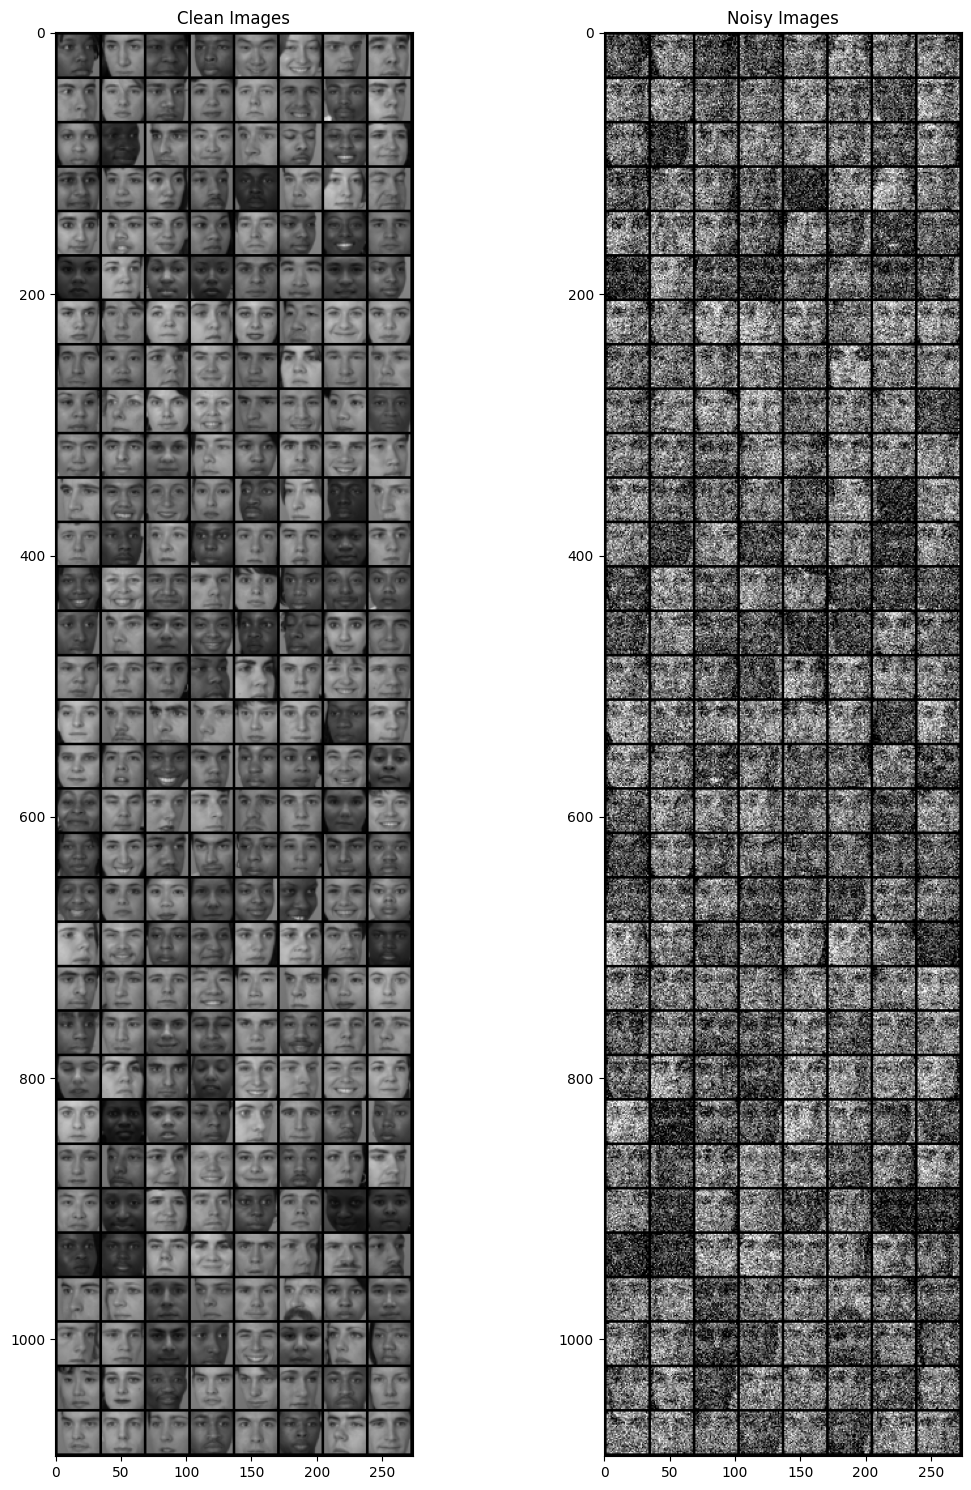

In [12]:
# Create noisy samples by noise_percentage * torch.randn_like(data0). 
# You can use torch.randn_like(data) * noise_percentage to generate noise based around the data's distribution
# These will just be temporary noisy images. You will add in the noise during the training_step of your Simple_AE class later on.

data = next(iter(train_loader))

# Create noisy data
noise_percentage = 0.2
noisy_data = data + noise_percentage * torch.randn_like(data)
noisy_data = torch.clip(noisy_data, 0., 1.) # Clip the data between 0 and 1. Look at the documentation for torch.clip()

# visualize clean dataset using torchvision grid
plt.figure(figsize=(12, 15))

plt.subplot(1, 2, 1)
plt.title("Clean Images")
plt.imshow(torchvision.utils.make_grid(data).permute(1, 2, 0))


# visualize noisy dataset using torchvision grid
plt.subplot(1, 2, 2)
plt.title("Noisy Images")
plt.imshow(torchvision.utils.make_grid(noisy_data).permute(1, 2, 0))


plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
    
### Task 2.2: Design your network architecture for AE <a class="anchor" id="t2_2"></a>

In this task, you will create the encoder and decoder modules that you will use within your "Simple_AE" class (which will be your DAE).

The encoder will just consist of one layer with an activation function. BatchNorm1d will also be added to the encoder to speed up convergence. The decoder will also be one layer but has no activation function. You do not need to put a BatchNorm1d here.

The rest of the hyperparameters can be found within the PDF.

_Note: We have provided additional optional material in the weekly lectures for batch normalization if you wish to learn more about it. This is a useful technique in speeding up training. To use BatchNorm1d, you simply have to put in the previous layer's number of input features as the input parameter. See the [PyTorch documentation](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html) for more information._

In [36]:
# Define your encoder class
# You will use one linear layer in the encoder class and pass it through BatchNorm1d() then LeakyReLU

class Encoder(nn.Module):    
    def __init__(self):
        super().__init__()
        
        # Encoder section

        # Define linear layer
        
        self.encoder = nn.Sequential(
            # Add Linear Layer
            nn.Linear(in_features=32*32, out_features=128),
            # Add BatchNorm1d() as the next one in the sequence. 
            nn.BatchNorm1d(128),
            # Then add LeakyReLU. Note BatchNorm1d takes an input argument.
            nn.LeakyReLU()
            
        )
        
    def forward(self, x):
        # Forward pass of your encoder
        #print("Original input shape to Encoder:", x.shape)
        x = x.view(x.size(0), -1)
        #print("Flattened input shape:", x.shape)
        encoded = self.encoder(x)
        return encoded
    
    
# Define your decoder class
# You will use one linear layer in the encoder class. No need for LeakyReLU because we have a sigmoid at the end

class Decoder(nn.Module):   
    def __init__(self):
        super().__init__()
        
        # Add Linear Layer

        # Decoder section
        self.decoder = nn.Sequential(
            # Add Linear Layer
            nn.Linear(in_features=128, out_features=32*32)
        )
        
    def forward(self, x):
        # Forward pass through your decoder        
        # Pass the output of your decoder into a sigmoid function
        # Ensure you reshape to B x C x H x W before returning the values

        x = self.decoder(x)
        
        x = torch.sigmoid(x)
    
        x = x.view(x.size(0), 1, 32, 32)

        
        return x

Create your autoencoder class '_Simple_AE_' using LightningModule and call the Encoder and Decoder Blocks you have defined above.

In [137]:
#Let's create a simple DAE based on MLP networks
class Simple_AE(pl.LightningModule):
    
    def __init__(self, learning_rate=1e-3):
        super().__init__()
        
        self.learning_rate = learning_rate  # Use learning rate provided
        self.criterion = nn.MSELoss()  # Define your loss
        
        self.encoder = Encoder()  # Initialise your encoder 
        self.decoder = Decoder()  # Initialise your decoder
        
    def forward(self, x):
        # Forward pass through encoder and decoder
        # Is the result the same shape as your original image? Worth to double check!
        #print("Input to AE:", x.shape)
        encoded = self.encoder(x)
        #print("Encoded output:", encoded.shape) 
        decoded = self.decoder(encoded)
        #print("Decoded output:", decoded.shape)


        return decoded
    
    def training_step(self, batch, batch_idx):  # There are additional steps here compared to previous implementations of your NN models. Read the comments carefully!
        x = batch  # Retrieve image from batch
        noisy_x = x + 0.2 * torch.randn_like(x)  # Add in noise to your data here
        noisy_x = torch.clip(noisy_x, 0., 1.) # Clip your data between 0 and 1. You can use torch.clip()
        
        output = self.forward(noisy_x)  # Remember, this is where we are training. So you will pass in your noisy_data to the encoder, and use that latent code to pass through your decoder
    
        loss = self.criterion(output, x) # Think about what your loss should be comparing against. There are 3 possibilities: original "x", predicted "x", and noisy "x". Which two are correct to predict?
                                        # If your model is not converging to a non-noisy output, this loss criterion might be why! (perhaps comparing two wrong values)
        
        
        
        self.log("train_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        
        return loss # Don't forget to return loss so that the gradients can be updated
    
    def validation_step(self, batch, batch_idx):  # There are additional steps here compared to previous implementations of your NN models. Read the comments carefully!
        # Validation step is very similar to the training_step
        x = batch
        noisy_x = x + 0.2 * torch.randn_like(x)
        noisy_x = torch.clip(noisy_x, 0., 1.)
         

        # Remember, this is where we are validating. So you will pass in your noisy_data to the encoder, and use that latent code to pass through your decoder
        output = self.forward(noisy_x)
        loss = self.criterion(output, x)


        # Calling self.log will surface up scalars for you in TensorBoard
        self.log("val_loss", loss, prog_bar=True,on_step=False, on_epoch=True)

        return loss
        
    def test_step(self, batch, batch_idx):  # There are additional steps here compared to previous implementations of your NN models. Read the comments carefully!
        # Test step is similar to the validation step
        
        # Remember, this is where we are testing. So you will pass in your noisy_data to the encoder, and use that latent code to pass through your decoder
        
        x = batch
        noisy_x = x + 0.2 * torch.randn_like(x)
        noisy_x = torch.clip(noisy_x, 0., 1.)
        
        output = self.forward(noisy_x)
        loss = self.criterion(output, x)

        # Calling self.log will surface up scalars for you in TensorBoard
        self.log("test_loss", loss, prog_bar=True)

        return loss
        
    
    def predict_step(self, batch, batch_idx):  # There are additional steps here compared to previous implementations of your NN models. Read the comments carefully!
        
        x = batch
        # You need to return predicted "x", noisy "x", and original x. That way you can compare the results with what is expected  ! 
        noisy_x = x + 0.2 * torch.randn_like(x)
        noisy_x = torch.clip(noisy_x, 0., 1.)

        predicted_x = self.forward(noisy_x)

        return {"predicted_x": predicted_x, "noisy_x": noisy_x, "original_x": x}
    


    def configure_optimizers(self):
        
        return torch.optim.Adam(self.parameters(), lr=self.learning_rate, weight_decay=1e-5)
    



    #####################
    # DATA RELATED HOOKS
    #####################

    def train_dataloader(self):
        return train_loader
    
    def val_dataloader(self):
        return valid_loader

    def test_dataloader(self):
        return test_loader

<div class="alert alert-block alert-info">
    
### Task 2.3: Train your model and evaluate the DAE results <a class="anchor" id="t2_3"></a>

In [140]:
# Initialize the model
model_ae = Simple_AE(learning_rate=1e-3)

# Define checkpoint callback function to save best model
checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        dirpath="checkpoints_task_2/",
        save_top_k=1,        # save the best model
        mode="min",
        every_n_epochs=1
    )


# Call the Trainer and train the model
trainer_task = pl.Trainer(
    accelerator="auto",
    #devices=1 if torch.cuda.is_available() else None,  # limiting got iPython runs
    max_epochs=50,
    callbacks=[checkpoint_callback],
    logger=CSVLogger(save_dir="logs_task_2/"),
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [141]:
# Train the Simple AE model
trainer_task.fit(model_ae)





LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type    | Params | Mode 
----------------------------------------------
0 | criterion | MSELoss | 0      | train
1 | encoder   | Encoder | 131 K  | train
2 | decoder   | Decoder | 132 K  | train
----------------------------------------------
263 K     Trainable params
0         Non-trainable params
263 K     Total params
1.054     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [142]:
# Test the model and report test accuracy and test loss
trainer_task.test(model_ae)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\dwx\anaconda3\envs\ECE4179_2\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:424: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss          0.0030776553321629763
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_loss': 0.0030776553321629763}]

Visiualise your experimental results. First, take a look at the accuracy for both training and validation. 

In [143]:
log_data = pd.read_csv("logs_task_2/lightning_logs/version_16/metrics.csv")


print(log_data.head())

   epoch  step  test_loss  train_loss  val_loss
0      0     4        NaN         NaN  0.033120
1      0     4        NaN    0.032558       NaN
2      1     9        NaN         NaN  0.032745
3      1     9        NaN    0.018344       NaN
4      2    14        NaN         NaN  0.031169


In [145]:

print(log_data.columns)


Index(['epoch', 'step', 'test_loss', 'train_loss', 'val_loss'], dtype='object')


In [151]:
#  train_loss  NaN ，（index % 2 == 0）
log_data.loc[log_data.index % 2 == 0, 'train_loss'] = log_data.loc[log_data.index % 2 == 0, 'train_loss'].dropna()
#  val_loss  NaN ，（index % 2 == 1）
log_data.loc[log_data.index % 2 == 1, 'val_loss'] = log_data.loc[log_data.index % 2 == 1, 'val_loss'].dropna()


processed_data = log_data.dropna(subset=['train_loss', 'val_loss'], how='all')

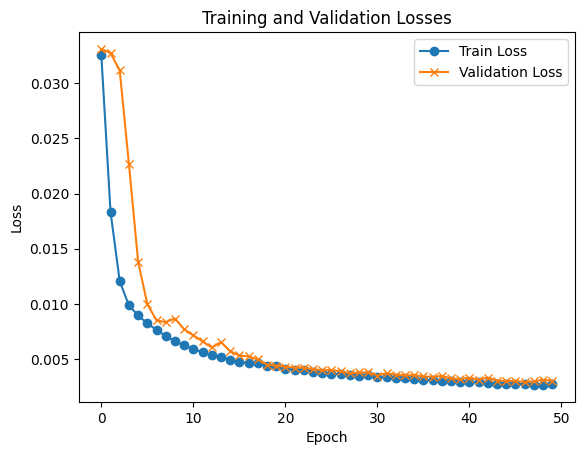

In [153]:
# Plot both training and validation losses

train_loss_data = processed_data.dropna(subset=['train_loss'])
val_loss_data = processed_data.dropna(subset=['val_loss'])

plt.figure()

# train_loss
plt.plot(train_loss_data['epoch'], train_loss_data['train_loss'], label='Train Loss', marker='o')

# val_loss
plt.plot(val_loss_data['epoch'], val_loss_data['val_loss'], label='Validation Loss', marker='x')


plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()

plt.show()


<div class="alert alert-block alert-info">
    
### Task 2.4: Visualise reconstructed images along with the clean data <a class="anchor" id="t2_4"></a>
    
Visualise some reconstructed images along with clean data and noisy data. You can use the predict function from your trainer. Reshape your output accordingly so that it is the same as the input image dimensions. Please plot at least 20 images, and make sure label your visualisations appropriately.

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

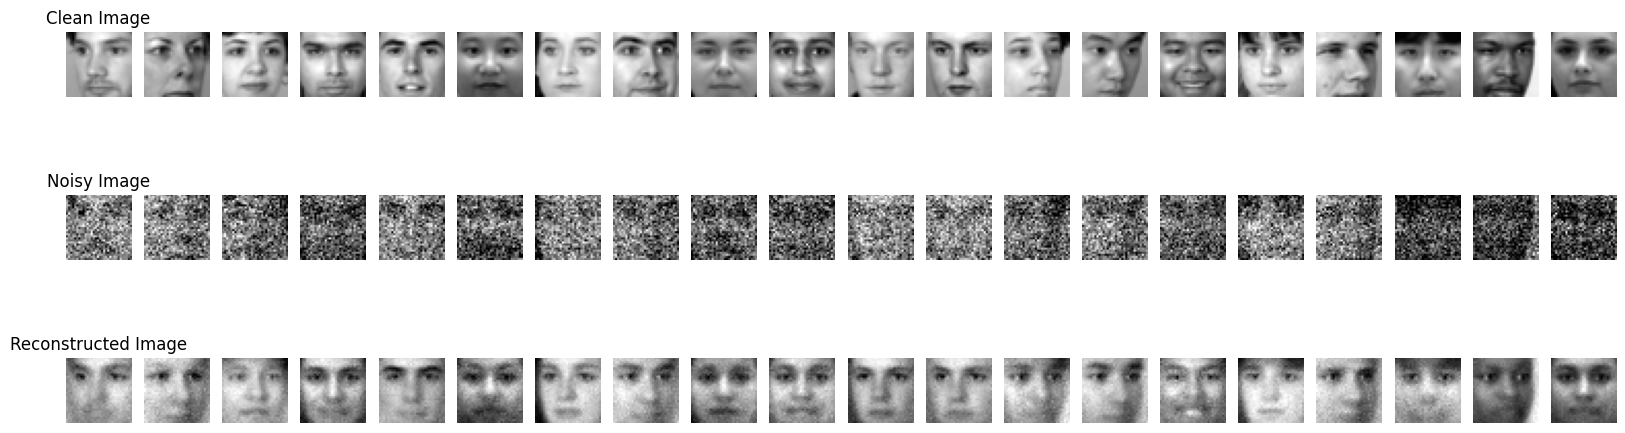

In [172]:
# Generate predictions using predict function
# Extract the predictions, noisy inputs, and clean inputs

predictions = trainer_task.predict(model_ae, test_loader)

reconstructed_images = predictions[0]['predicted_x']
noisy_images = predictions[0]['noisy_x']
original_images = predictions[0]['original_x']


fig, axes = plt.subplots(3, 20, figsize=(20, 6))

for i in range(20):
    
    axes[0, i].imshow(original_images[i].squeeze(), cmap='gray')  
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Clean Image')  
    
    
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')  
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Noisy Image')  
    

    axes[2, i].imshow(reconstructed_images[i].squeeze(), cmap='gray')  
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_title('Reconstructed Image')  


plt.show()

<div class="alert alert-block alert-info">
    
### Task 2.5: Peak Signal To Noise Ratio (PSNR) <a class="anchor" id="t2_5"></a>
    
Here, you need to Compute Peak Signal-to-Noise Ratio (PSNR) for test dataset. The PSNR is a commonly used metric to measure the quality of a reconstructed or denoised signal or image. The PSNR is calculated as the ratio of the peak signal power to the noise power, typically measured in decibels (dB). PSNR can be defined as </br>
</br>
    $$\mathrm{PSNR} = 10 \cdot \log_{10}\Big\lbrace\frac{{\mathrm{MAX}^2}}{{\mathrm{MSE}}}\Big\rbrace$$

Where:

`PSNR` is the Peak Signal-to-Noise Ratio in dB.

`MAX` is the maximum possible pixel value (e.g., 255 for an 8-bit image).

`MSE` is the Mean Squared Error between the original and the reconstructed (or denoised) image. It's calculated as the average of squared pixel-wise differences between the two images.

Show the PSNR values for:
- Between the noisy image and original image
- Between the reconstructed image and original image

In [174]:
from torchmetrics.image import PeakSignalNoiseRatio

psnr = PeakSignalNoiseRatio()

# Put model into eval() mode so it turns off batch norm
model_ae.eval() 

# Collect predictions and true labels
psnr_values_noisy_n_original = []
psnr_values_reconstructed_n_original = []

# Iterate over the entire test dataset and make predictions
# Make sure to use torch.no_grad below so that it does not keep track of gradients
with torch.no_grad():
    for batch in test_loader:
        
        
        # Compute PSNR between noisy images and original images
        psnr_noisy = psnr(noisy_images, original_images)
        psnr_values_noisy_n_original.append(psnr_noisy.item())
        
        # Compute PSNR between reconstructed images and original images
        psnr_reconstructed = psnr(reconstructed_images, original_images)
        psnr_values_reconstructed_n_original.append(psnr_reconstructed.item())
        
        
print(f"Mean PSNR value between noisy image and original image: {np.mean(psnr_values_noisy_n_original)}")
print(f"Mean PSNR value between reconstructed image and original image: {np.mean(psnr_values_reconstructed_n_original)}")

Mean PSNR value between noisy image and original image: 12.892901420593262
Mean PSNR value between reconstructed image and original image: 23.678293228149414


<div class="alert alert-block alert-success">
    
### Task 2.6: Discussion Question <a class="anchor" id="t2_6"></a>
    
### Question:

1. How does the DAE reduce the amount of noise from the input?

2. Can you think of a reason why leaky ReLU was chosen over ReLU in this case?

3. What can you say about the PSNR values? Ensure you mention whether higher or lower PSNR values are better. 

4. How could we further improve the model? 
    
### Answer

1. First we added noise to the input data, and the noise-added data was passed into the encoder. Encoders compress data, trying to capture key features of the input data while ignoring noise. The features obtained by the encoder are passed to the decoder. The decoder attempts to recover the data as close as possible to the original input. Throughout the process, DAE will continuously compare the gap between the model's reconstructed output and the original noise-free input, continuously narrowing the gap, and then learn how to denoise.

2. When using ReLU, if the output of a neuron is always zero, it may stop activating and never recover during training. Leaky ReLU will provide a small non-zero gradient when the input is a negative value, which ensures that even if the neuron is not activated, the gradient can still be transmitted, thus improving the training stability of the model.

3. PSNR is a measure of image quality. The higher the PSNR value, the better the image quality.
The results obtained in this task:
The PSNR value between the noise image and the original image is low, indicating that the noise image is significantly different from the original image.
The PSNR value between the reconstructed image and the original image is high, indicating that DAE successfully reduces noise and makes the reconstructed image closer to the original image.
 
4. - Try to use different levels or types of noise during training
   - Adjust hyperparameters such as learning rate, weight decay, or optimizer
   - Add more layers or increase the number of neurons in the encoder/decoder
